# Sampling Distributions and the Central Limit Theorem

This notebook will guide you through one of the most important concepts in statistics: the Central Limit Theorem (CLT).

Please read these instructions carefully before you begin:

- **AI use**: You may use AI to *ask questions* if you are stuck or need clarification. You're also free to use AI to complete individual lines of code. Do not, however, copy and paste from AI or use a tool like Copilot to write whole sections of code. The purpose of this assignment is for you to gain fluency with statistical concepts through hands-on coding.
- **Questions**: Look for cells marked with `Q:`. These contain questions you must answer in Markdown.
- **Markdown**: Use Markdown cells to explain your results, interpret outputs, and format your answers neatly.
- **Random Seeds**: Set random seeds before each simulation so your results are reproducible.
- **Visualizations**: Create clear, well-labeled plots. Always include titles, axis labels, and legends where appropriate.

By the end of this assignment, you should have a deep intuition for how sample means behave and why the Central Limit Theorem is so powerful.

When you've finished your work, ensure your notebook runs top-to-bottom without errors, then commit and push your changes to GitHub.

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducibility. 
# Feel free to change this to another 
# integer to see other other results.
np.random.seed(20251007)

### Helper Functions

These functions are provided to help you with the assignment.

In [184]:
def dice_statistics(n_dice):
    """
    Returns the expected mean and standard deviation 
    for the sum of n_dice fair six-sided dice.
    
    Parameters:
    -----------
    n_dice : int
        Number of dice to roll
    
    Returns:
    --------
    mean : float
        Expected value of the sum
    std : float
        Standard deviation of the sum
    """
    mean = n_dice * 3.5
    variance = n_dice * 35/12  # variance of single die is 35/12
    std = np.sqrt(variance)
    return mean, std

def theoretical_se(population_std, sample_size):
    """
    Calculates theoretical standard error.
    
    Parameters:
    -----------
    population_std : float
        Population standard deviation 
    sample_size : int
        Sample size (n)
    
    Returns:
    --------
    float
        Theoretical standard error
    """
    return population_std / np.sqrt(sample_size)

---
## Part 1: Dice Simulation

We'll start by simulating dice rolls to build intuition about sampling distributions in a simple, controlled environment.

### Why start with dice?
- We know the exact population parameters (mean = 3.5, std ≈ 1.71 for a single die)
- We can easily generate thousands of "samples"
- The underlying distribution is simple and discrete
- We can see how the CLT works before dealing with messy real data


### Part 1a: Single Die

Let's start by understanding the distribution of a single die. Simulate rolling a single six-sided die 10,000 times. 

**Tasks:**
1. Generate 10,000 random die rolls (values 1-6)
2. Create a histogram showing the distribution
3. Calculate the mean and standard deviation
4. Compare to the theoretical values

**Hint:** Use `np.random.randint(1, 7, size=10000)` to simulate die rolls

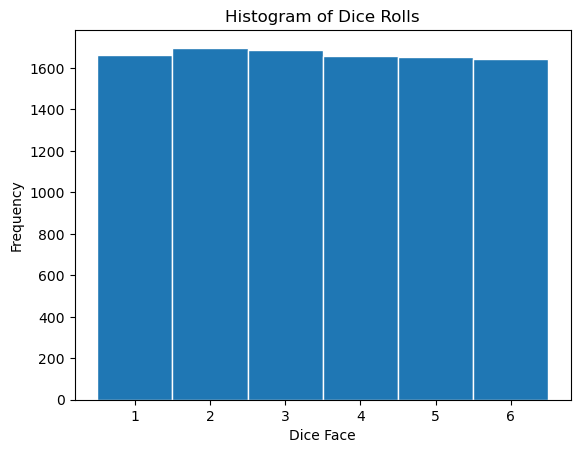

In [185]:
# Your code here
d_rolls = np.random.randint(1,7,size=10000)
bins = np.arange(1,8) - 0.5
plt.hist(d_rolls,bins=bins, edgecolor = "white")
plt.title("Histogram of Dice Rolls")
plt.xlabel("Dice Face")
plt.ylabel("Frequency")
plt.show()

In [186]:
mean = np.mean(d_rolls)
std = np.std(d_rolls)

print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {std:.2f}")

Mean: 3.49
Standard Deviation: 1.70


In [187]:
#theoretical mean and std
theo_mean, theo_std = dice_statistics(1)
print(f"Theoretical Mean: {theo_mean:.2f}")
print(f"Theoretical Std: {theo_std:.2f}")

Theoretical Mean: 3.50
Theoretical Std: 1.71


Q: What is the mean and standard deviation of your simulated die rolls? How close are they to the theoretical values (mean = 3.5, std ≈ 1.71)? What shape does the distribution have?

A: <!-- Your answer here --> Emprirical Result -> Mean:3.49, SD:1.70 and Theoretical -> Mean:3.50, SD:1.71. Shape of the distribution: All six faces appear with roughly equal frequency. Perfect match to a fair die.

---

### Part 1b: Sum of Multiple Dice

Now let's see what happens when we roll multiple dice and sum them. This will help us understand how distributions combine.

**Tasks:**
1. Write a function `roll_dice(n_dice)` that returns the sum of rolling n dice
2. For each number of dice [1, 2, 3, 5, 10], roll 10,000 times
3. Create subplots showing the distribution for each number of dice
4. Calculate and display mean and std for each

**What to observe:** As you add more dice, notice how the distribution shape changes.

In [188]:
def roll_dice(n_dice):
    """
    Simulates rolling n_dice dice and returns their sum.
    
    Parameters:
    -----------
    n_dice : int
        Number of dice to roll
    
    Returns:
    --------
    int
        Sum of all dice
    """
    return np.sum(np.random.randint(1, 7, size=n_dice))

Now simulate rolling 1, 2, 5, 10, 20, and 100 dice. Plot the resulting sums, calculate the empirical means and standard deviations and compare those to the theoretical values. 

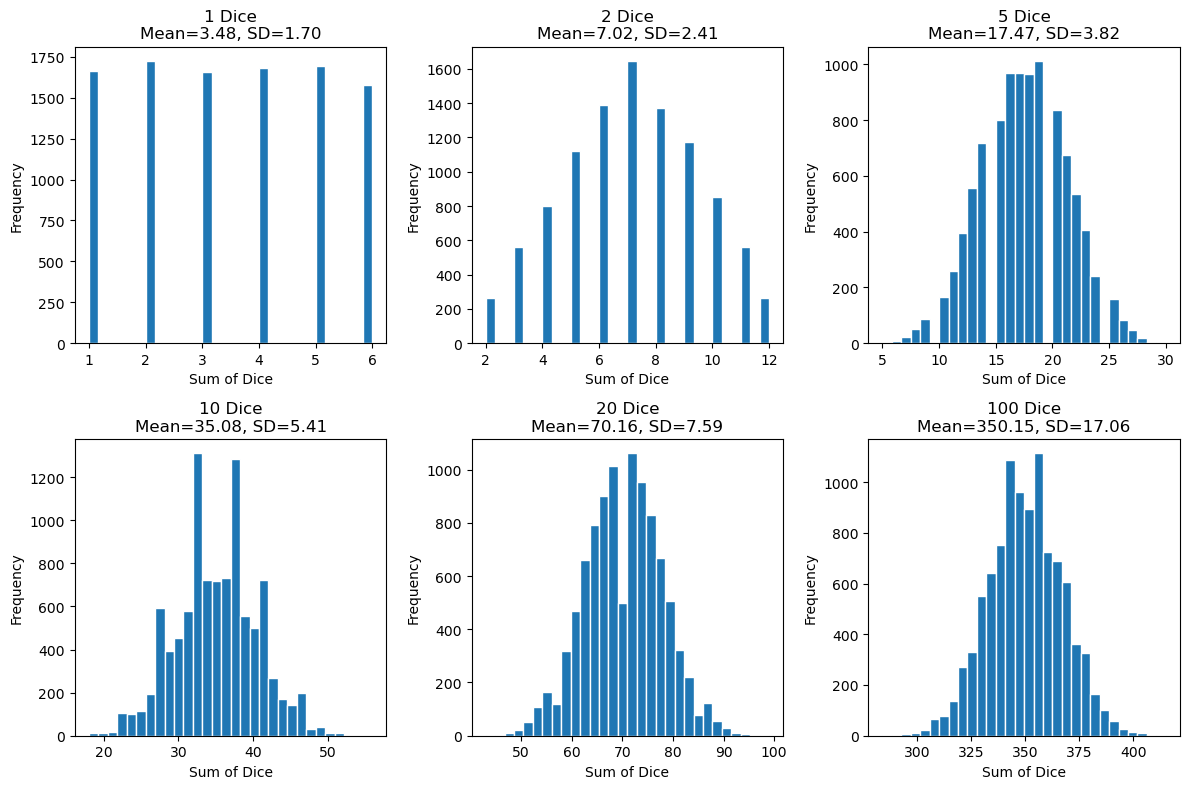

In [189]:
# Your code here
dice_counts = [1, 2, 5, 10, 20, 100]
n_simulations = 10_000

plt.figure(figsize=(12, 8))

for i, n_dice in enumerate(dice_counts, 1):
    #Simulate 10,000 trials of n_dice dice each
    sums = [roll_dice(n_dice) for _ in range(n_simulations)]
    
    #Empirical stats
    empirical_mean = np.mean(sums)
    empirical_std = np.std(sums)
    
    #Theoretical stats
    theo_mean, theo_std = dice_statistics(n_dice)
    
    #Plot
    plt.subplot(2, 3, i)
    plt.hist(sums, bins=30, edgecolor="white")
    plt.title(f"{n_dice} Dice\nMean={empirical_mean:.2f}, SD={empirical_std:.2f}")
    plt.xlabel("Sum of Dice")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Q: What do you notice about the shape of the distribution as you add more dice? Does it start to look more like any particular distribution? Why do you think this happens?

A: <!-- Your answer here --> The distribution transitions from uniform(flat) to bell-shaped(normal distribution) as more dice are added.
1 die: Completely uniform, all values are equally likely
2-5 dice: Triangular/peaked shape emerging
10-20 dice: Clear bell curve forming
100 dice: Nearly perfect normal distribution.
This demonstrates the Central Limit Theorem, summing many independent random variables converges to a normal distribution.

--- 

### Part 1c: Sampling Distribution of the Mean

Now we get to the heart of the Central Limit Theorem. We're going to create **sampling distributions**.

**What's a sampling distribution?**
- Take a sample of size n from a population
- Calculate the mean of that sample
- Repeat this many times
- The distribution of all those sample means is the "sampling distribution"

**Our experiment:**
We'll focus on rolling 5 dice. For different sample sizes (n = 5, 10, 30, 100, 500):
1. Take 1,000 samples, where each sample consists of rolling 5 dice n times
2. Calculate the mean of each sample (the average sum across n rolls)
3. Plot the distribution of these 1,000 sample means

**Key insight:** Even though individual rolls are uniform, the means will be normally distributed.


In [190]:
# Your code here
def roll_dice_5():
    return roll_dice(5)

In [191]:
sample_sizes = [5,10,30,100,500]
n_samples = 1000

for n in sample_sizes:
    rolls = np.random.randint(1, 7, size=(n_samples,n, 5))
    roll_sums = np.sum(rolls, axis=2)  
    sample_means = np.mean(roll_sums, axis=1)
    
    print(f"Sample size {n} → Mean of sample means: {np.mean(sample_means):.2f}, SD: {np.std(sample_means):.2f}")

Sample size 5 → Mean of sample means: 17.48, SD: 1.72
Sample size 10 → Mean of sample means: 17.48, SD: 1.19
Sample size 30 → Mean of sample means: 17.53, SD: 0.69
Sample size 100 → Mean of sample means: 17.50, SD: 0.38
Sample size 500 → Mean of sample means: 17.50, SD: 0.16


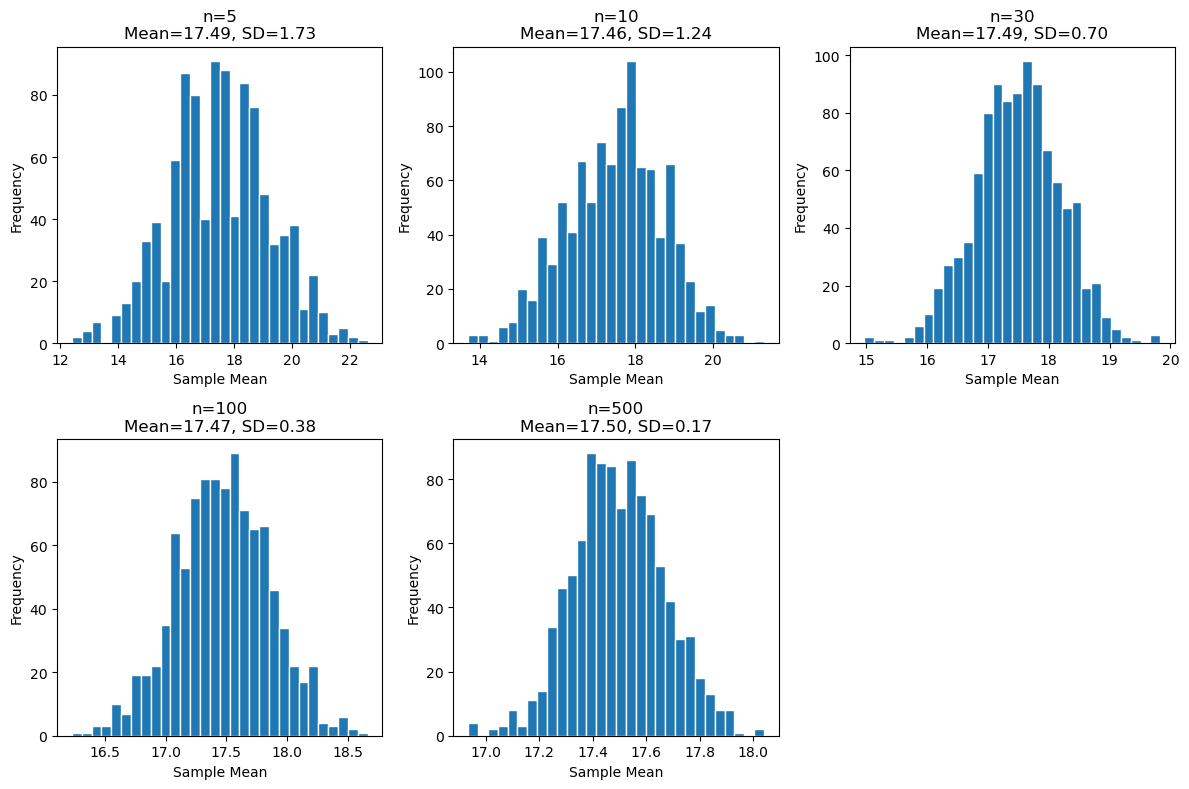

In [192]:
plt.figure(figsize=(12, 8))

for i, n in enumerate(sample_sizes, 1):
   
    rolls = np.random.randint(1, 7, size=(n_samples, n, 5))
    roll_sums = np.sum(rolls, axis=2)   
    sample_means = np.mean(roll_sums, axis=1)
    
    plt.subplot(2, 3, i)
    plt.hist(sample_means, bins=30, edgecolor="white")
    plt.title(f"n={n}\nMean={np.mean(sample_means):.2f}, SD={np.std(sample_means):.2f}")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Q: How does the shape of the sampling distribution change as sample size (n) increases? What happens to the spread? Do all the distributions center around the same value?

A: <!-- Your answer here -->  As sample size increases, the sampling distribution becomes narrower and more concentrated but the spread decreases. All distributions remain bell-shaped (normal) and center around the same mean (~17.5), but with increasingly tight clustering. Basically this shows that larger sample produce more precise, reliable estimates of the true population mean.

---

### Part 1d: Standard Error Analysis

Let's verify that the standard error formula SE = σ/√n actually works.

**Tasks:**
1. For each sample size, calculate the empirical SE (standard deviation of your sample means)
2. Calculate the theoretical SE using the formula sigma/sqrt(n)
3. Create a comparison table and plot
4. Analyze how well the formula predicts reality

In [193]:
# Your code here
mean_dice_5, std_dice_5 = dice_statistics(5)
print(mean_dice_5, std_dice_5)

17.5 3.8188130791298667


In [194]:
sample_sizes = [5, 10, 30, 100, 500]
n_samples = 1000
results = []
for n in sample_sizes:
    rolls = np.random.randint(1, 7, size=(n_samples, n, 5))  
    roll_sums = np.sum(rolls, axis=2)         
    sample_means = np.mean(roll_sums, axis=1) 

    # Empirical SE (from simulation)
    empirical_se = np.std(sample_means)
    
    # Theoretical SE using helper
    theo_se = theoretical_se(std_dice_5, n)
    
    results.append((n, empirical_se, theo_se))


In [160]:
df_sample = pd.DataFrame(results, columns=['Sample Size', 'Empirical SE', 'Theoretical SE'])
print(df_sample)

   Sample Size  Empirical SE  Theoretical SE
0            5      1.741542        1.707825
1           10      1.230668        1.207615
2           30      0.684461        0.697217
3          100      0.400820        0.381881
4          500      0.171435        0.170783


Q: How well does the theoretical formula (σ/√n) predict the actual standard error? Does the match get better or worse as sample size increases? Why do you think this is?

A: <!-- Your answer here --> The formula (σ/√n) predicts how much sample means vary. In our simulation, the calculated SE from the samples was very close to the theoretical SE. The match gets better for bigger sample sizes because larger samples reduce random variation and make the sample means more stable.

---

## Part 2: Honda Census

Now we'll apply these concepts to real data. You have a complete census of all Honda listings from Craigslist in California from July 2023 onward (approximately 111,000 listings).

**The big question:** Does the Central Limit Theorem work with real, messy data that's not normally distributed?

**What makes this different from dice:**
- The population distribution is likely skewed (most cars are cheaper, few are expensive)
- We have missing data and outliers
- The data represents real economic behavior, not a mathematical ideal

**Why this matters:** In the real world, you'll rarely work with normally distributed populations. The CLT is powerful precisely because it works anyway!

### Part 2a: Understand the Population

First, let's load and clean the data, then understand what our population looks like.

**Tasks:**
1. Load the Honda census data
2. Clean the price data and filter to reasonable values
3. Calculate population parameters (mean price μ and standard deviation σ)
4. Create a histogram to visualize the distribution
5. Assess whether the distribution is normal


In [195]:
# Your code here. Take as many cells as needed. 
# Don't spend more than 20 minutes cleaning these data. 
listings = pd.read_csv("california_hondas.txt", sep = "\t")
listings.head()

,state,location,time_posted,name,make,model,year,odometer,price,title,...,drive,cylinders,fuel,type,transmission,condition,title_text,latitude,longitude,url
0,California,ventura,2024-07-17 17:21:34,Honda Passport 1/4 ton nominal,honda,passport,2002.0,141994.0,850.0,clean,...,NaN,6 cylinders,gas,SUV,automatic,good,2002 Honda Passport,34.280385,-119.198160,https://ventura.craigslist.org/cto/d/ventura-2...
1,California,losangeles,2024-07-17 12:39:03,Honda Prelude,honda,prelude,1998.0,233000.0,6500.0,clean,...,NaN,NaN,gas,NaN,automatic,NaN,1998 Honda Prelude,33.886700,-118.126500,https://losangeles.craigslist.org/lgb/cto/d/be...
2,California,inlandempire,2024-07-17 10:04:48,Honda Accord Hybrid Touring,honda,accord hybrid,2021.0,27343.0,28700.0,clean,...,rwd,4 cylinders,hybrid,sedan,automatic,like new,2021 Honda Hybrid Accord,33.841900,-117.604300,https://inlandempire.craigslist.org/cto/d/coro...
3,California,sfbay,2024-07-16 20:36:15,honda passport,honda,passport,1998.0,278609.0,3000.0,clean,...,NaN,NaN,gas,SUV,automatic,NaN,1998 Honda Passport,37.435200,-121.895000,https://sfbay.craigslist.org/sby/cto/d/milpita...
4,California,losangeles,2024-07-16 11:57:42,Honda Clarity PLUG-IN Hybrid TOURING,honda,clarity plug-in hybrid,2019.0,42000.0,17500.0,salvage,...,fwd,4 cylinders,hybrid,sedan,automatic,excellent,"2019 Honda Clarity Touring 42,000 Mi",34.047204,-118.248015,https://losangeles.craigslist.org/lac/cto/d/lo...


In [196]:
listings['price'] = pd.to_numeric(listings['price'], errors='coerce')

In [197]:
listings['price'].describe()

count    108933.000000
mean       8161.277134
std        6583.269240
min           0.000000
25%        3900.000000
50%        6200.000000
75%       10500.000000
max      175000.000000
Name: price, dtype: float64

In [198]:
listings = listings[(listings['price'] >= 1000) & (listings['price'] <= 10000)]

In [199]:
population_mean = listings['price'].mean()
population_std = listings['price'].std()
print(f"Population mean price: ${population_mean:.2f}")
print(f"Population standard deviation: ${population_std:.2f}")

Population mean price: $5293.15
Population standard deviation: $2261.84


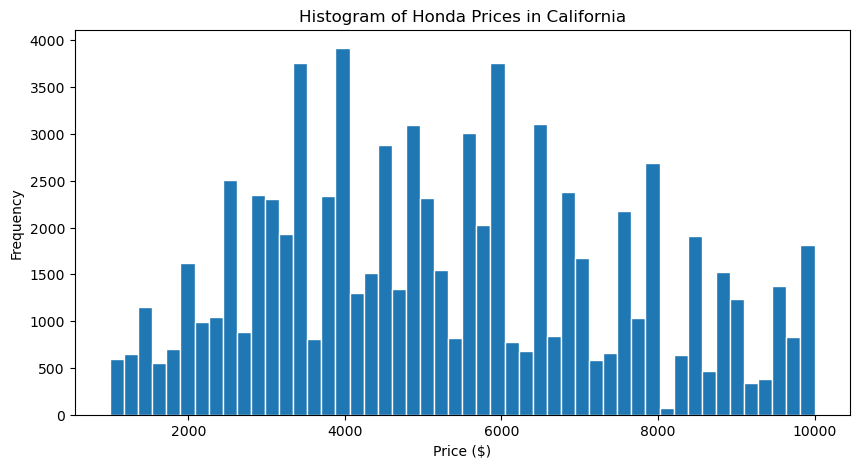

In [200]:
plt.figure(figsize=(10,5))
plt.hist(listings['price'], bins=50, edgecolor='white')
plt.title("Histogram of Honda Prices in California")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

Q: Is the price distribution approximately normal? What shape does it have? How does the mean compare to the median? What does this tell you about the population?

A: <!-- Your answer here --> The price distribution is not normal. Prices are relatively evenly spread across the $1,000-$10,000 range with no clear bell-shaped peak. The population lacks the bell-curve shape of a normal distribution


--- 

### Part 2b: Sampling Distributions and Standard Error

Now let's verify that the Central Limit Theorem works with real data. We'll take samples of different sizes and see if:
1. The sampling distributions become approximately normal (even though the population is skewed)
2. The standard error follows the formula SE = σ/√n

**Tasks:**
1. For each sample size [30, 50, 100, 200, 500], take 1,000 samples
2. Calculate the mean of each sample
3. Plot the sampling distributions
4. Compare empirical SE to theoretical SE

**Key question:** Does CLT work even with skewed data?

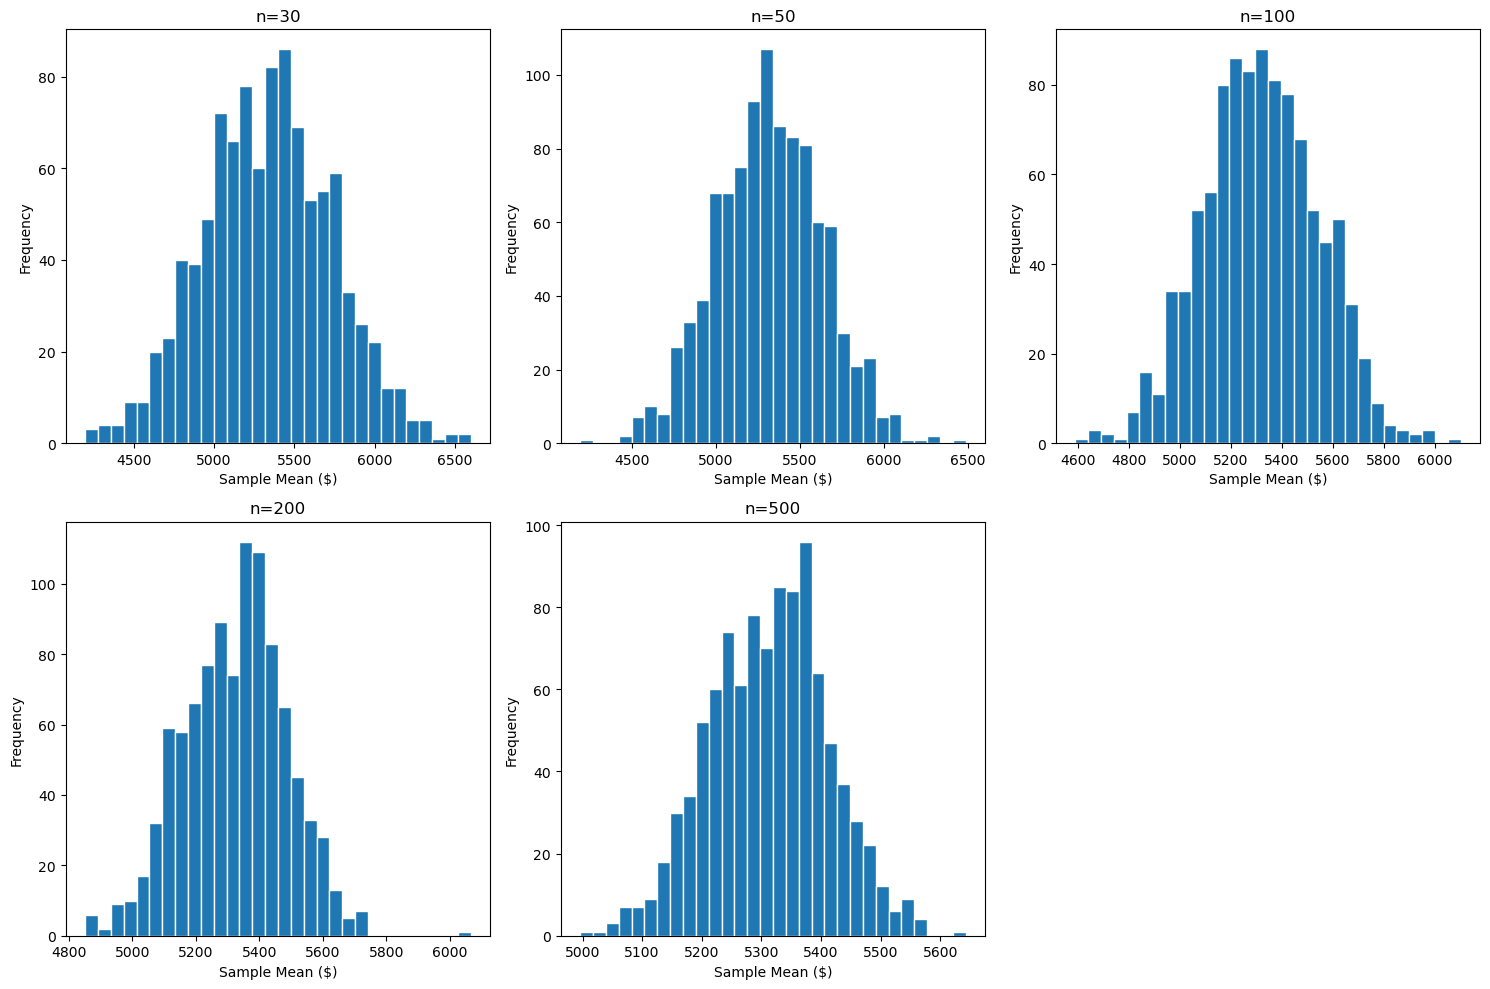

In [209]:
# Your code here
sample_size = [30, 50, 100, 200, 500]
n_sampled = 1000
results = []
population_prices = listings['price'].values
population_std = listings['price'].std()

plt.figure(figsize=(15, 10))

for i, n in enumerate(sample_size):

    samples = np.random.choice(population_prices, size=(n_samples, n), replace=True)
    sample_means = samples.mean(axis=1)
    
    empirical_se = sample_means.std()
    theo_se_value = theoretical_se(population_std, n)

    results.append((n, empirical_se, theo_se_value))
    
    #subplot
    plt.subplot(2, 3, i+1)  
    plt.hist(sample_means, bins=30, edgecolor='white')
    plt.title(f"n={n}")
    plt.xlabel("Sample Mean ($)")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [202]:
df_price = pd.DataFrame(results, columns=['Sample Size', 'Empirical SE', 'Theoretical SE'])
print(df_price)

   Sample Size  Empirical SE  Theoretical SE
0           30    435.546754      412.952789
1           50    325.701995      319.871855
2          100    220.270771      226.183558
3          200    154.155360      159.935928
4          500    106.817154      101.152362


Q: What happens to the sampling distributions as n increases? Do they all look approximately normal, even though the population is skewed? How well does the theoretical formula (σ/√n) predict the actual standard error?

A: <!-- Your answer here -->As the sample size increases, the sampling distributions become smoother and more normal, even though the population is skewed. The theoretical formula (σ/√n) predicts the standard error accurately, and the match improves as n gets larger.

--- 

### Part 2c: Different Variables (Optional Challenge)

If you want an extra challenge, see if the Central Limit Theorem works equally well for a different variable.

**Tasks:**
1. Clean the odometer data (remove missing values, filter to reasonable range)
2. Calculate population parameters for odometer
3. Create sampling distributions for n=30, 100, and 500
4. Compare the results to what you found with price data

In [203]:
# Optional code here
listings['odometer'] = pd.to_numeric(listings['odometer'], errors='coerce')
listings = listings.dropna(subset=['odometer'])

In [204]:
listings["odometer"].describe()

count    7.882300e+04
mean     1.657087e+05
std      1.346464e+05
min      0.000000e+00
25%      1.300000e+05
50%      1.600000e+05
75%      1.920000e+05
max      1.000000e+07
Name: odometer, dtype: float64

In [205]:
listings = listings[(listings['odometer'] >= 1000) & (listings['odometer'] <= 300000)]

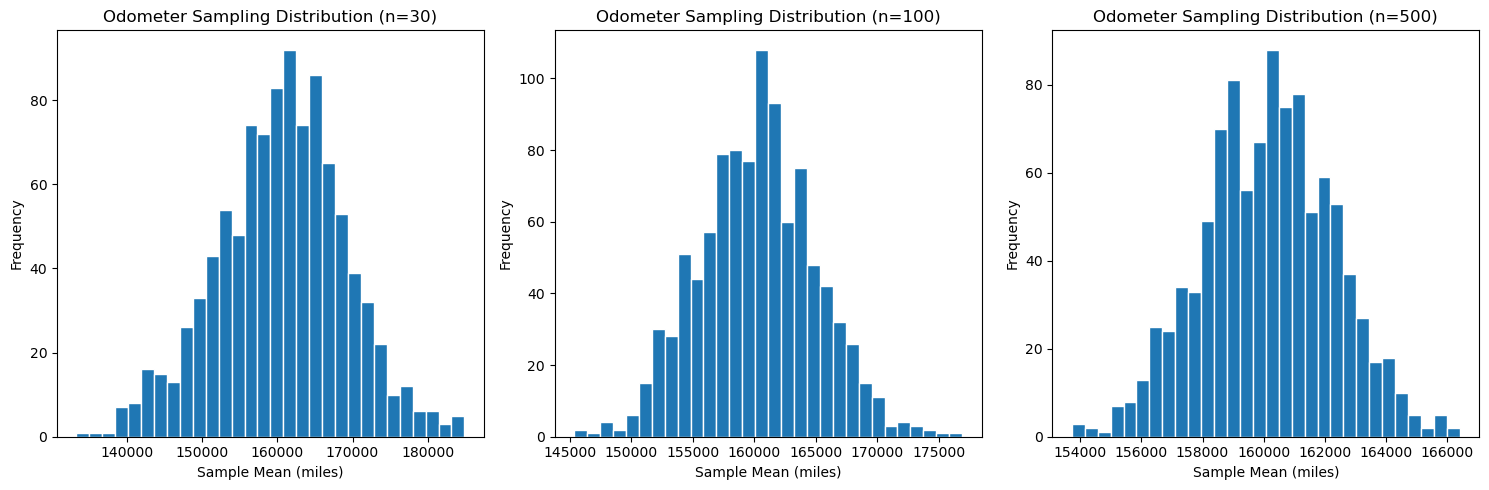

In [212]:
sample_size = [30,100, 500]
n_samples = 1000
results = []
population_odometer = listings['odometer'].values
population_std_odo = listings['odometer'].std()

plt.figure(figsize=(15, 5))

for i, n in enumerate(sample_size):
    #sample
    samples = np.random.choice(population_odometer, size=(n_samples, n), replace=True)
    sample_means = samples.mean(axis=1)

    empirical_se = sample_means.std()
    theo_se_value = theoretical_se(population_std_odo, n)
    results.append((n, empirical_se, theo_se_value))
    
    #subplot for each sample size
    plt.subplot(1, 3, i + 1)
    plt.hist(sample_means, bins=30, edgecolor='white')
    plt.title(f"Odometer Sampling Distribution (n={n})")
    plt.xlabel("Sample Mean (miles)")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [213]:
df_odo = pd.DataFrame(results, columns=['Sample Size', 'Empirical SE', 'Theoretical SE'])
print(df_odo)

   Sample Size  Empirical SE  Theoretical SE
0           30   8461.100278     8733.080583
1          100   4730.105649     4783.305232
2          500   2136.863853     2139.159131


For both odometer and price, the standard error (SE) decreases as the sample size increases. Odometer SEs are larger than price SEs because odometer values are bigger and more spread out. In all cases, the empirical SE closely matches the theoretical SE, and the sampling distributions become more normal with larger sample sizes. This demonstrates that the Central Limit Theorem works even for skewed population data.